# Rational weights as duplicated uniform matching

This notebook generates `fig:matching-rational-duplication`.  It uses the same
canonical disk-to-annulus geometry as `fig:matching-resolution-and-weights`, but
with fewer displayed atoms.  Rational weights $a_i=k_i/N$ and $b_j=\ell_j/N$
are represented by duplicating each source and target atom, solving a uniform
assignment, and collapsing the duplicated assignment back onto the original
locations.


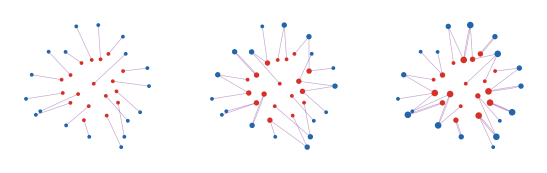

In [1]:

from pathlib import Path
import sys

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        NOTEBOOK_DIR = candidate.resolve()
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
from scipy.optimize import linear_sum_assignment

from figure_style import (
    RED,
    BLUE,
    VIOLET,
    canonical_matching_clouds,
    figure_dir,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

OUT = figure_dir("matching-rational-duplication")
THUMB = NOTEBOOK_DIR / "thumbnails" / "matching-rational-duplication.png"
THUMB.parent.mkdir(exist_ok=True)

# Same generator and seed as Figure 1.5, with half as many atoms for readability.
source, target, _ = canonical_matching_clouds(seed=2027, n_source=18)
source *= 0.98
target *= 0.98
n = len(source)

cases = [
    ("uniform", np.ones(n, dtype=int), np.ones(n, dtype=int)),
    ("binary", np.tile([1, 2], n // 2), np.tile([2, 1], n // 2)),
    ("ternary", np.tile([1, 2, 3], n // 3), np.roll(np.tile([1, 2, 3], n // 3), 1)),
]


def duplicate_cloud(points, multiplicities):
    locations, owners = [], []
    for i, k in enumerate(multiplicities):
        for _ in range(int(k)):
            locations.append(points[i])
            owners.append(i)
    return np.asarray(locations), np.asarray(owners)


def draw_curve(ax, a, b, offset, color=VIOLET):
    mid = 0.5 * (a + b)
    direction = b - a
    normal = np.array([-direction[1], direction[0]])
    normal = normal / max(np.linalg.norm(normal), 1e-12)
    ctrl = mid + offset * normal
    path = MplPath([a, ctrl, b], [MplPath.MOVETO, MplPath.CURVE3, MplPath.CURVE3])
    patch = PathPatch(path, facecolor="none", edgecolor=color, lw=0.48, alpha=0.43, zorder=1)
    ax.add_patch(patch)


def solve_case(k, ell):
    xs, io = duplicate_cloud(source, k)
    ys, jo = duplicate_cloud(target, ell)
    cost = np.sum((xs[:, None, :] - ys[None, :, :]) ** 2, axis=2)
    rows, cols = linear_sum_assignment(cost)
    return [(int(io[r]), int(jo[c])) for r, c in zip(rows, cols)]


xlim, ylim = padded_limits(np.vstack([source, target]), pad=0.13)


def draw_panel(ax, k, ell):
    pairs = solve_case(k, ell)
    counts = {}
    for i, j in pairs:
        counts[(i, j)] = counts.get((i, j), 0) + 1
    for (i, j), c in counts.items():
        offsets = np.linspace(-0.024, 0.024, c) if c > 1 else [0.0]
        for offset in offsets:
            draw_curve(ax, source[i], target[j], offset)
    # Matplotlib scatter sizes are areas, so these are proportional to multiplicity.
    ax.scatter(source[:, 0], source[:, 1], s=7.5 * k, color=RED, edgecolor="none", zorder=3)
    ax.scatter(target[:, 0], target[:, 1], s=7.5 * ell, color=BLUE, edgecolor="none", zorder=3)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    remove_axes(ax)


fig, axs = plt.subplots(1, 3, figsize=(6.8, 2.25))
for ax, (name, k, ell) in zip(axs, cases):
    draw_panel(ax, k, ell)
    single, single_ax = plt.subplots(figsize=(2.20, 2.15))
    draw_panel(single_ax, k, ell)
    save_pdf(single, OUT / f"{name}.pdf", pad_inches=0.035)
    plt.close(single)

fig.savefig(THUMB, dpi=220, bbox_inches="tight", pad_inches=0.04)
plt.show()
